In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#use this to update 2 opinions of a single agent with 2 opinions
def update_agent(agent, agents, R):

    #find the distance between this agent and all the agents based on 2 opinions
    norm = np.linalg.norm(agent - agents, axis=1)

    #select the agents within the bound R
    selected = np.where(norm <= R)[0]

    #update this agent based on these agents per opinion
    update = np.average(agents[selected], axis=0)

    return update

#use this to update only 1 opinion of a single agent with 2 opinions
def update_agent_1op(agent, agents, R):

    #find the distance between this agent and all the agents based on 2 opinions
    norm = np.linalg.norm(agent - agents, axis=1)

    #select the agents within the bound R
    selected = np.where(norm <= R)[0]

    #update this agent first opnion only these agents
    update = np.copy(agent)
    update[0] = np.average(agents[selected,0])

    return update

In [3]:

def plot3dhisto(input_data):
    fig = plt.figure(figsize=(6, 5))
    ax3d = fig.add_subplot(111, projection='3d')

    x, y = input_data[:, 0], input_data[:, 1]

    # make it a 10×10 histogram
    bins = 10
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[0, 1], [0, 1]])

    # find bin centers
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    xpos, ypos = np.meshgrid(x_centers, y_centers, indexing='ij')

    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos)

    # defind bar sizes and spacing
    spacing = 0.8
    dx = spacing * (xedges[1] - xedges[0])
    dy = spacing * (yedges[1] - yedges[0])

    dz = hist.ravel()

    ax3d.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

    # Labels
    ax3d.set_xlabel("Opinion 1")
    ax3d.set_ylabel("Opinion 2")
    ax3d.set_zlabel("Count")
    ax3d.set_title("3D Histogram of opinions")

    ax3d.set_xlim(0, 1)
    ax3d.set_ylim(0, 1)
    ax3d.set_zlim(0, dz.max() * 1.1 if dz.max() > 0 else 1)

    plt.tight_layout()
    plt.show()


In [4]:

from matplotlib import cm

def plot3dhisto_heat(input_data):

    fig = plt.figure(figsize=(10, 4), constrained_layout=True)
    gs = fig.add_gridspec(1, 2)

    ax3d = fig.add_subplot(gs[0, 0], projection='3d')
    ax2d = fig.add_subplot(gs[0, 1])

    x, y = input_data[:, 0], input_data[:, 1]

    # make it a 10×10 histogram
    bins = 10
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[0, 1], [0, 1]])

    # find bin centers
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    xpos, ypos = np.meshgrid(x_centers, y_centers, indexing='ij')

    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos)

    # defind bar sizes and spacing
    spacing = 0.8 
    dx = spacing * (xedges[1] - xedges[0])
    dy = spacing * (yedges[1] - yedges[0])

    dz = hist.ravel()


    norm = plt.Normalize(dz.min(), dz.max() if dz.max() > 0 else 1)
    colors = cm.viridis(norm(dz))

    ax3d.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, shade=True)
    ax3d.set_xlabel("Opinion 1")
    ax3d.set_ylabel("Opinion 2")
    ax3d.set_zlabel("Count")
    ax3d.set_title("3D Histogram of opinions")

    ax3d.set_xlim(0, 1)
    ax3d.set_ylim(0, 1)
    ax3d.set_zlim(0, dz.max() * 1.1 if dz.max() > 0 else 1)  # small headroom at top

    # create a heatmap based on the values of the bins
    mesh = ax2d.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto')
    ax2d.set_xlabel("Opinion 1")
    ax2d.set_ylabel("Opinion 2")
    ax2d.set_title("Opinions Heatmap")
    ax2d.set_aspect('equal')
    ax2d.set_xlim(0, 1)
    ax2d.set_ylim(0, 1)

    # add colorbar
    cbar = fig.colorbar(mesh, ax=ax2d, fraction=0.046, pad=0.04)
    cbar.set_label("Count")

    plt.show()


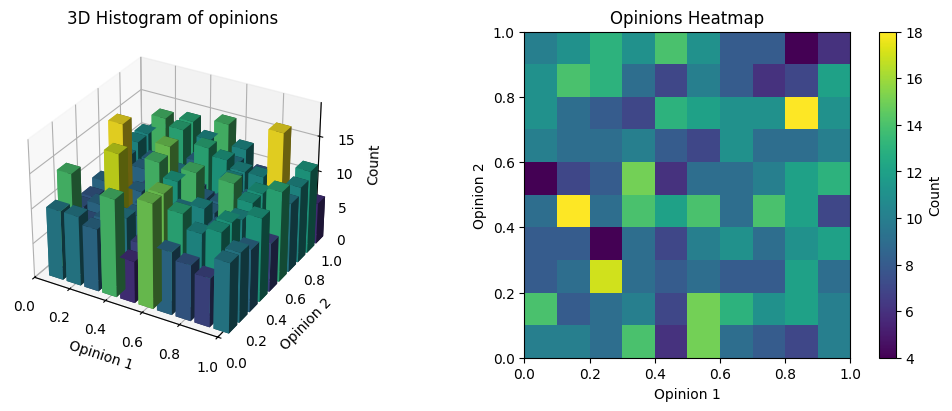

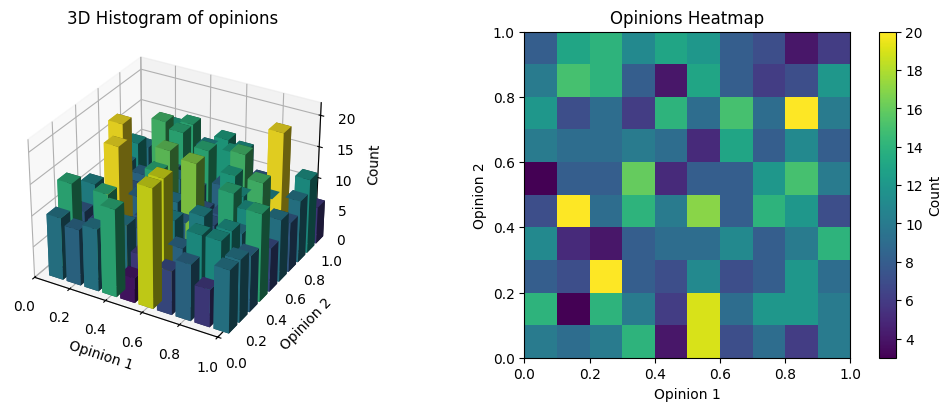

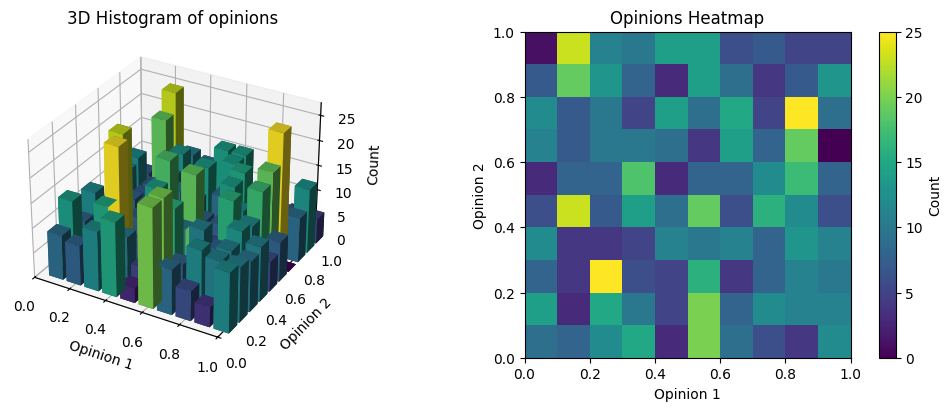

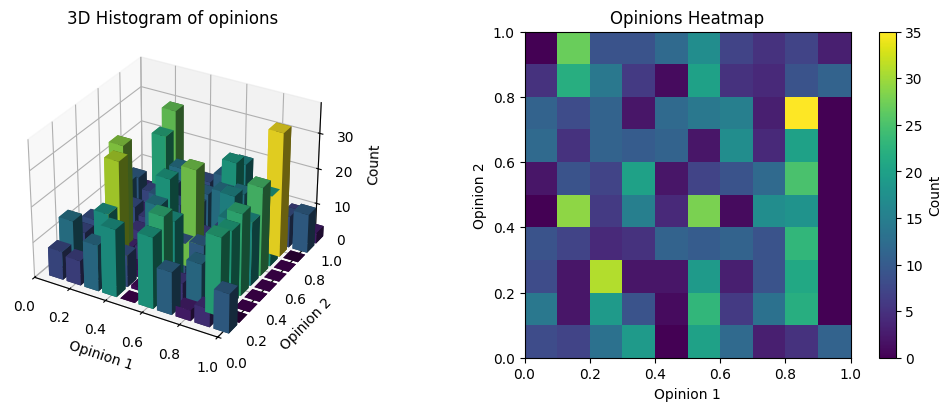

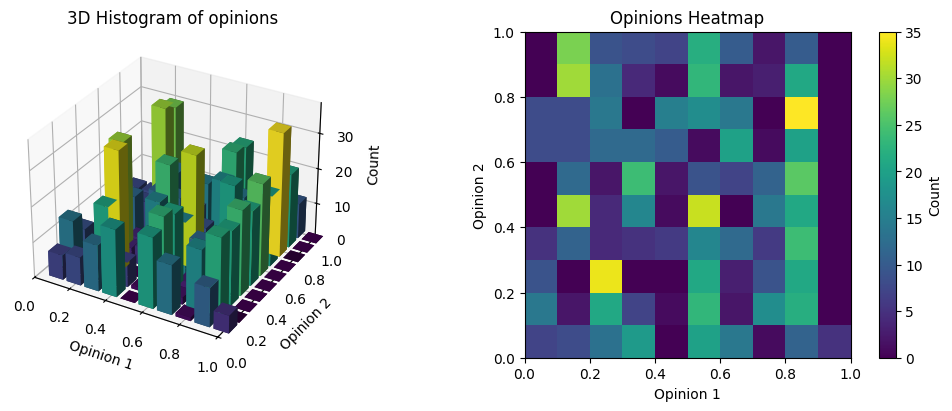

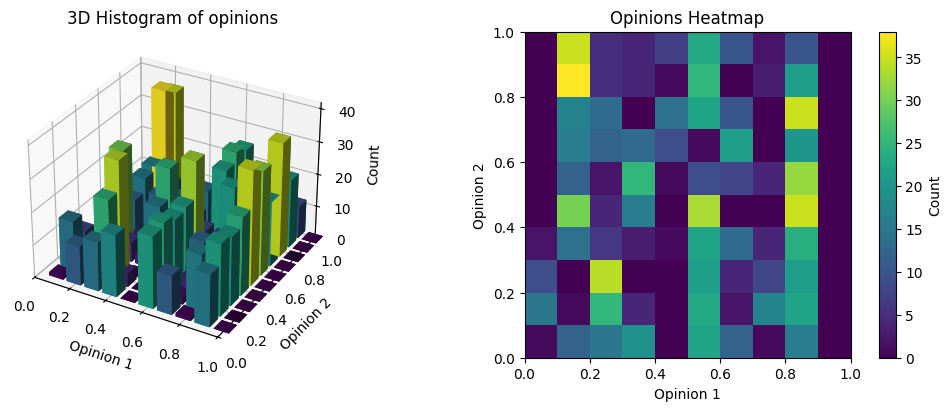

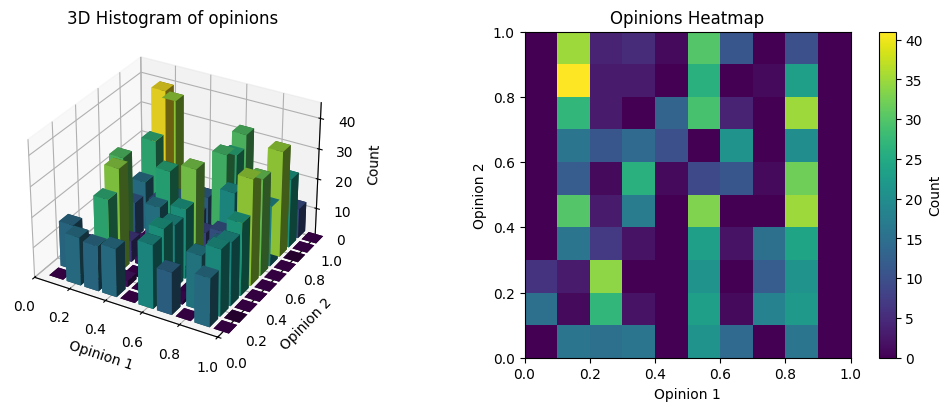

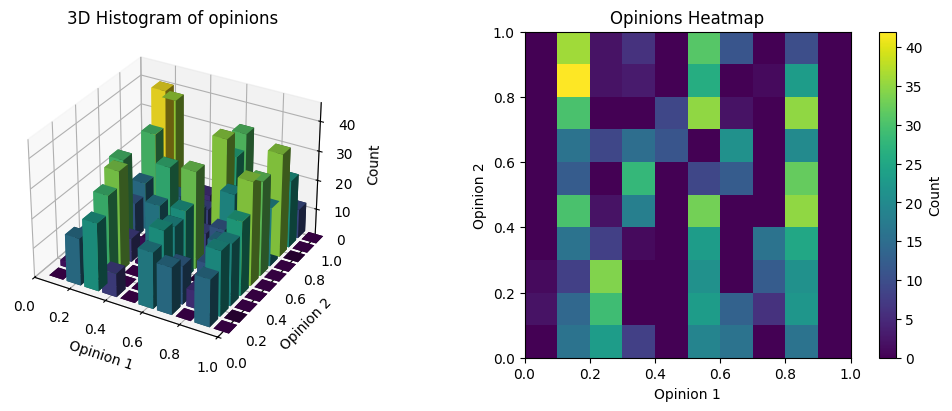

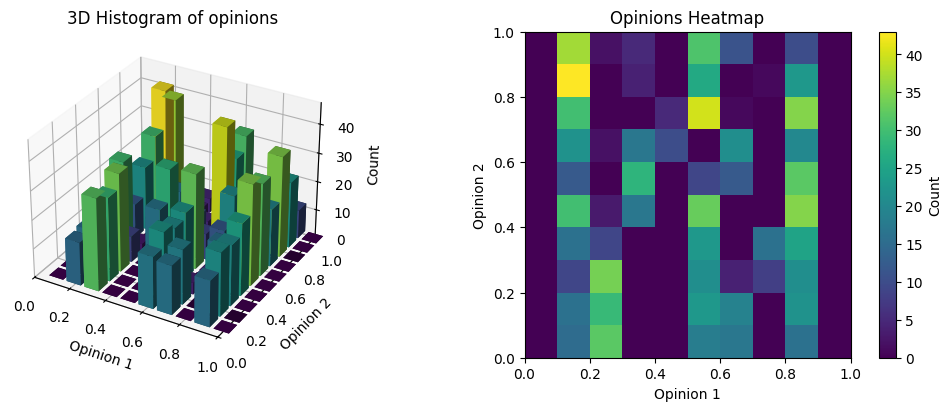

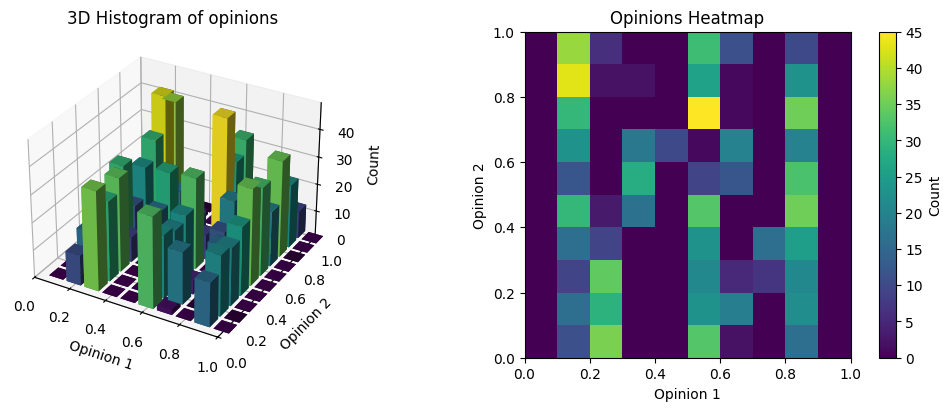

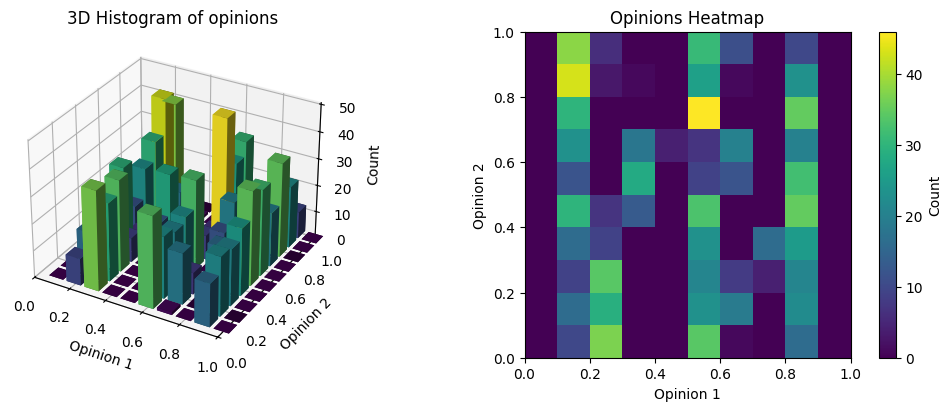

In [5]:
R = 0.1
n = 1000
steps = 10

#initialize the agents
agents = np.random.uniform(0, 1, (n, 2))
agents_initial = np.copy(agents)

#initialize array to store opinions over time
agents_history = np.zeros((steps+1, n, 2))
agents_history[0, :, :] = agents


#do t time steps (main loop)

#do an intial plot at T=0
plot3dhisto_heat(agents)

for r in range(steps):

    #make a temp list of agents
    agents_next = np.zeros((n, 2))

    #loop over all agents
    for i, agent in enumerate(agents):
        agents_next[i] = update_agent_1op(agent, agents, R)

    #update the agents list
    agents = np.copy(agents_next)
    agents_history[r+1, :] = agents

    plot3dhisto_heat(agents)
    # plot3dhisto(agents)

    # This is a diffrent function that graphs only 2d histogram without the heatmap

